In [1]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt

d:\Projects\semantic_response_convergence\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
domain = "android"

cqadup = load_dataset("BeIR/cqadupstack", domain)

cqadup

DatasetDict({
    corpus: Dataset({
        features: ['_id', 'title', 'text'],
        num_rows: 22998
    })
    queries: Dataset({
        features: ['_id', 'title', 'text'],
        num_rows: 699
    })
})

In [4]:
from datasets import load_dataset

qrels = load_dataset("BeIR/cqadupstack-qrels")

qrels

d:\Projects\semantic_response_convergence\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ali29\.cache\huggingface\hub\datasets--BeIR--cqadupstack-qrels. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating test split: 100%|██████████| 23703/23703 [00:00<00:00, 1986246.33 examples/s]


DatasetDict({
    test: Dataset({
        features: ['query-id', 'corpus-id', 'score'],
        num_rows: 23703
    })
})

In [5]:
qrels.keys()

dict_keys(['test'])

In [6]:
for split_name in qrels.keys():
    print(split_name)
    print(qrels[split_name].column_names)
    print(qrels[split_name][0])
    print()

test
['query-id', 'corpus-id', 'score']
{'query-id': 11546, 'corpus-id': 18572, 'score': 1}



In [11]:
cqadup["corpus"][0]

{'_id': '51829',
 'title': 'How can show android tablet as a external storage to PC?',
 'text': "I want to send files to android tablet with a application from PC. - I can send files directly to tablet (2.3 android OS) PC see it as a external usb drive. - But i can't send files to tablet (4.2 android OS), because PC see it as a portable media player.(MTP) - How can i fix this problem ? - How can show my device as a external drive? my application that sent files written via Delphi."}

In [12]:
cqadup["queries"][0]

{'_id': '11546',
 'title': '',
 'text': 'Android chroot ubuntu - is it possible to get ubuntu to recognise usb devices'}

In [14]:
len(cqadup["corpus"])

22998

In [15]:
len(cqadup["queries"])

699

In [16]:
import pandas as pd

qrels_df = pd.DataFrame(qrels["test"])

qrels_df.head()

,query-id,corpus-id,score
0,11546,18572,1
1,82440,23010,1
2,82440,77782,1
3,82440,37697,1
4,82440,76985,1


In [17]:
qrels_df["query-id"].nunique()

12569

In [18]:
qrels_df.groupby("query-id").size().describe()

count    12569.000000
mean         1.885830
std          5.015485
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        263.000000
dtype: float64

In [19]:
import pandas as pd

corpus_df = pd.DataFrame(cqadup["corpus"])

corpus_df.head()

,_id,title,text
0,51829,How can show android tablet as a external stor...,I want to send files to android tablet with a ...
1,11541,How can I hide some contacts from dialer?,I am playing around with my brand new Motorola...
2,18572,Access to android usb port from chroot linux?,> **Possible Duplicate:** > Android chroot ...
3,11547,"Android doesn't say it's Ericsson, hard restar...",I bought a Sony Ericsson X8 and saw on YouTube...
4,11545,Best tool for benchmarking roms/kernels/wifi/3g,I want to do a comparison of different types o...


In [20]:
queries_df = pd.DataFrame(cqadup["queries"])

queries_df.head()

,_id,title,text
0,11546,,Android chroot ubuntu - is it possible to get ...
1,82440,,problem in installing apps in karbonn A5i
2,36706,,LG L3 : difference between system memory and i...
3,19971,,List of ROMs for HTC Flyer
4,64676,,What is the difference between AOSP and CM/AOKP?


In [21]:
print("Corpus size:", len(corpus_df))
print("Query size:", len(queries_df))
print("Qrels size:", len(qrels_df))

Corpus size: 22998
Query size: 699
Qrels size: 23703


In [22]:
print("\nCorpus Missing Values")
print(corpus_df.isna().sum())

print("\nQueries Missing Values")
print(queries_df.isna().sum())


Corpus Missing Values
_id      0
title    0
text     0
dtype: int64

Queries Missing Values
_id      0
title    0
text     0
dtype: int64


In [23]:
empty_titles = (
    queries_df["title"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print("Empty query titles:", empty_titles)

Empty query titles: 699


In [24]:
queries_df["query_length"] = (
    queries_df["text"]
    .fillna("")
    .str.split()
    .apply(len)
)

queries_df["query_length"].describe()

count    699.000000
mean       9.184549
std        3.590259
min        2.000000
25%        6.000000
50%        9.000000
75%       11.000000
max       21.000000
Name: query_length, dtype: float64

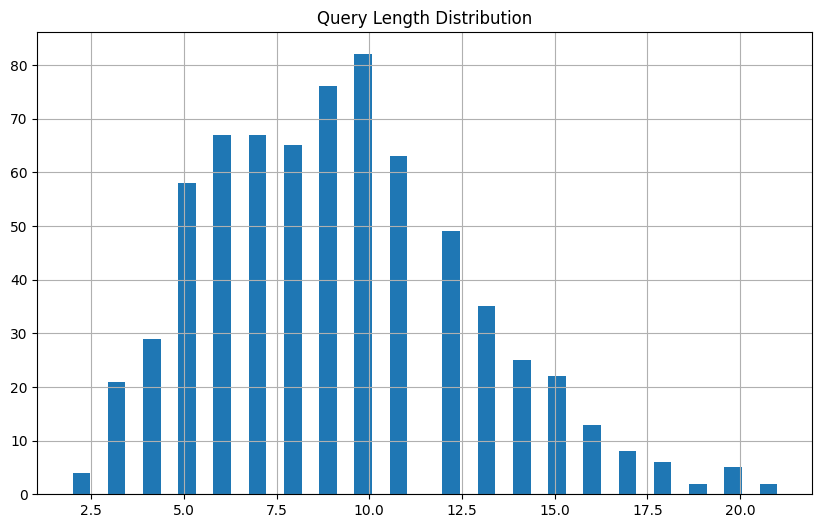

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

queries_df["query_length"].hist(
    bins=40
)

plt.title("Query Length Distribution")

plt.show()

In [26]:
corpus_df["doc_length"] = (
    corpus_df["text"]
    .fillna("")
    .str.split()
    .apply(len)
)

corpus_df["doc_length"].describe()

count    22998.000000
mean        94.392034
std         86.824172
min          3.000000
25%         47.000000
50%         74.000000
75%        115.000000
max       3004.000000
Name: doc_length, dtype: float64

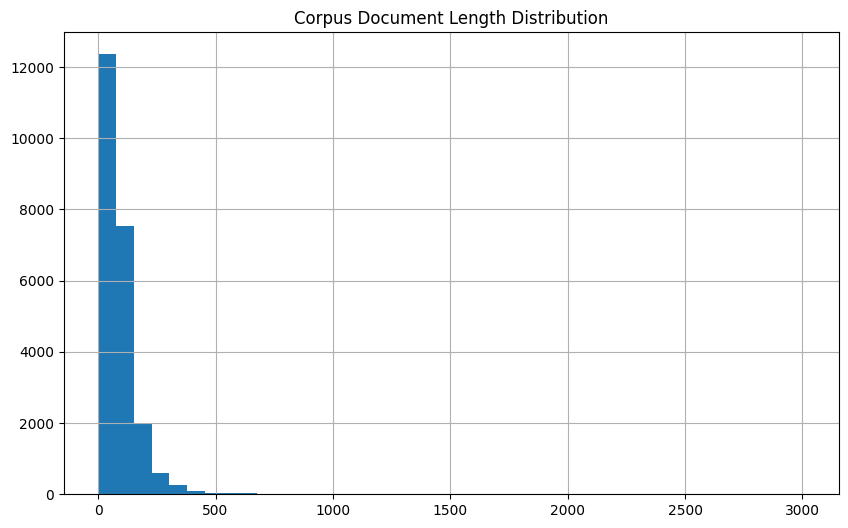

In [27]:
plt.figure(figsize=(10,6))

corpus_df["doc_length"].hist(
    bins=40
)

plt.title("Corpus Document Length Distribution")

plt.show()

In [28]:
relevant_docs_per_query = (
    qrels_df
    .groupby("query-id")
    .size()
)

relevant_docs_per_query.describe()

count    12569.000000
mean         1.885830
std          5.015485
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        263.000000
dtype: float64

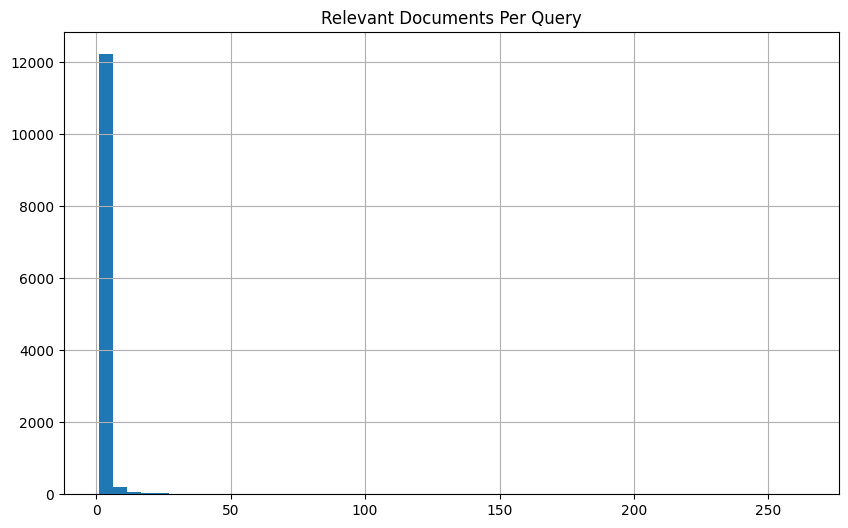

In [29]:
plt.figure(figsize=(10,6))

relevant_docs_per_query.hist(
    bins=50
)

plt.title(
    "Relevant Documents Per Query"
)

plt.show()